# Pipeline Results
End-to-end summary of the infrastructure imagery curation pipeline.
Shows funnel metrics, tile quality, and example outputs.

Run the full pipeline first:
```bash
python pipeline.py
```
Or run with a small sample:
```bash
# in pipeline.py, set SAMPLE_PER_TYPE = 3, then:
python pipeline.py
```

In [1]:
# check_pbf.py — run this first
import osmium

class Counter(osmium.SimpleHandler):
    def __init__(self):
        super().__init__()
        self.nodes = 0
        self.ways  = 0
        self.rels  = 0

    def node(self, n):
        self.nodes += 1

    def way(self, w):
        self.ways += 1
        if self.ways <= 5:
            print(f"  Way {w.id}: tags={dict(w.tags)}")

    def relation(self, r):
        self.rels += 1

c = Counter()
c.apply_file("data/pbf/north-america-latest.osm_power_only.osm.pbf")
print(f"nodes={c.nodes:,}  ways={c.ways:,}  relations={c.rels:,}")

: 

In [42]:
import sys
sys.path.insert(0, '..')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagery import stretch_rgb
from dataset import DatasetAssembler

## Configuration

In [43]:
DATASET_DIR  = './data/dataset_us-northeast_v1'
ASSETS_CSV   = './data/us-northeast_all_assets.csv'
DEDUPED_CSV  = './data/us-northeast_deduped_assets.csv'

## Pipeline funnel

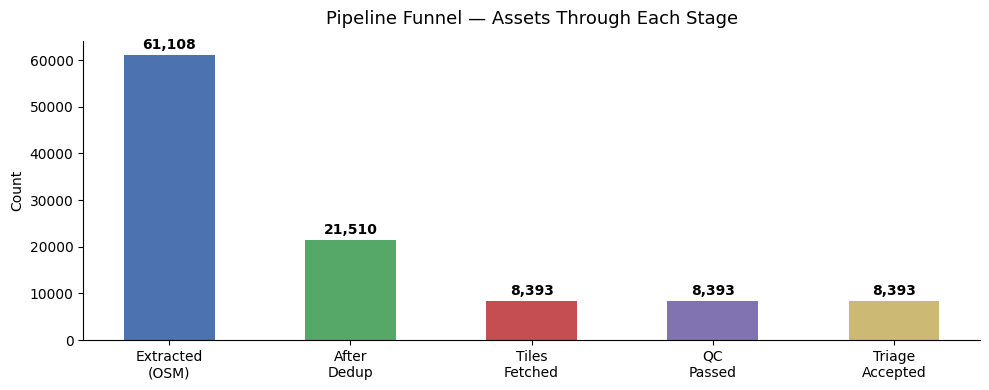

Saved pipeline_funnel.png


In [44]:
# Load counts from each stage
df_raw    = pd.read_csv(ASSETS_CSV)   if os.path.exists(ASSETS_CSV)   else pd.DataFrame()
df_deduped = pd.read_csv(DEDUPED_CSV) if os.path.exists(DEDUPED_CSV) else pd.DataFrame()

assembler = DatasetAssembler(DATASET_DIR)
manifest  = assembler.load_manifest()
df_dataset = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('bbox','image_shape')}
    for r in manifest['records']
])

stages = {
    'Extracted\n(OSM)':       len(df_raw),
    'After\nDedup':            len(df_deduped),
    'Tiles\nFetched':          manifest['n_tiles'],
    'QC\nPassed':              manifest['n_tiles'],  # update if you track separately
    'Triage\nAccepted':        len(df_dataset),
}

fig, ax = plt.subplots(figsize=(10, 4))
colors  = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars    = ax.bar(stages.keys(), stages.values(), color=colors, width=0.5)

for bar, val in zip(bars, stages.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stages.values())*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Pipeline Funnel — Assets Through Each Stage', fontsize=13, pad=12)
ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('pipeline_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pipeline_funnel.png')

## Asset type breakdown

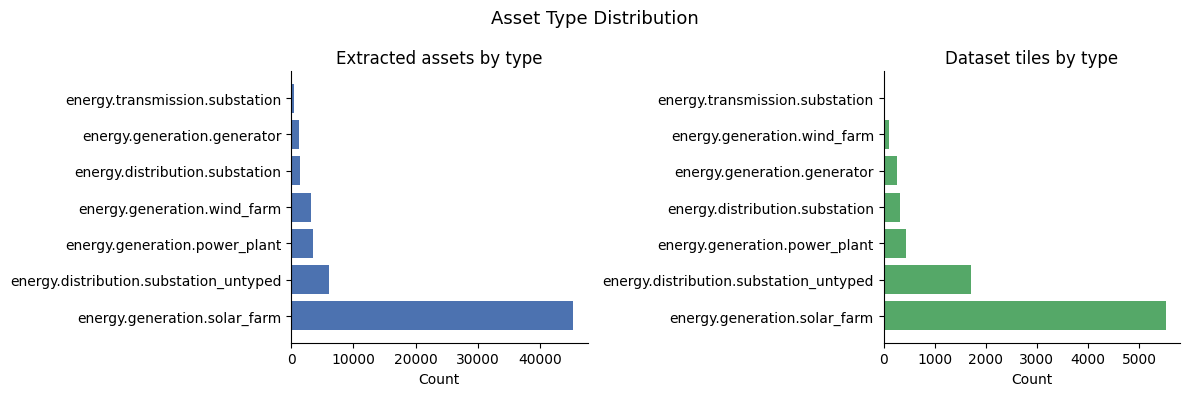

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw extraction
if not df_raw.empty:
    counts = df_raw['asset_type'].value_counts()
    axes[0].barh(counts.index, counts.values, color='#4C72B0')
    axes[0].set_title('Extracted assets by type')
    axes[0].set_xlabel('Count')
    axes[0].spines[['top','right']].set_visible(False)

# Dataset tiles
if not df_dataset.empty:
    counts2 = df_dataset['asset_type'].value_counts()
    axes[1].barh(counts2.index, counts2.values, color='#55A868')
    axes[1].set_title('Dataset tiles by type')
    axes[1].set_xlabel('Count')
    axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Asset Type Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('asset_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Source breakdown

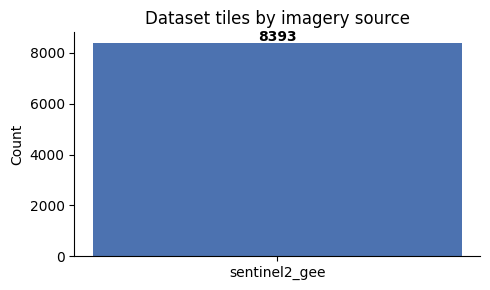

In [46]:
if not df_dataset.empty:
    source_counts = df_dataset['source'].value_counts()
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(source_counts.index, source_counts.values,
           color=['#4C72B0','#55A868','#C44E52'][:len(source_counts)])
    ax.set_title('Dataset tiles by imagery source')
    ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
    for i, (idx, val) in enumerate(source_counts.items()):
        ax.text(i, val + max(source_counts)*0.01, str(val),
                ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('source_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()

## Confidence distribution

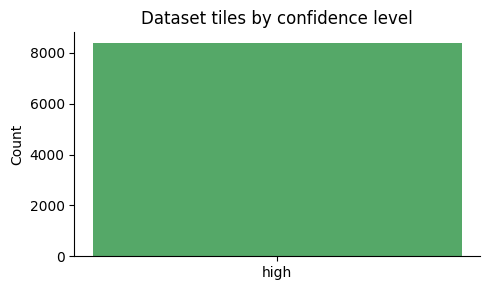

In [47]:
if not df_dataset.empty and 'confidence' in df_dataset.columns:
    conf_counts = df_dataset['confidence'].value_counts()
    colors_conf = {'high': '#55A868', 'low': '#CCB974', 'contradiction': '#C44E52'}
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(conf_counts.index,
           conf_counts.values,
           color=[colors_conf.get(c, '#4C72B0') for c in conf_counts.index])
    ax.set_title('Dataset tiles by confidence level')
    ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

## Example tiles — one grid per asset type

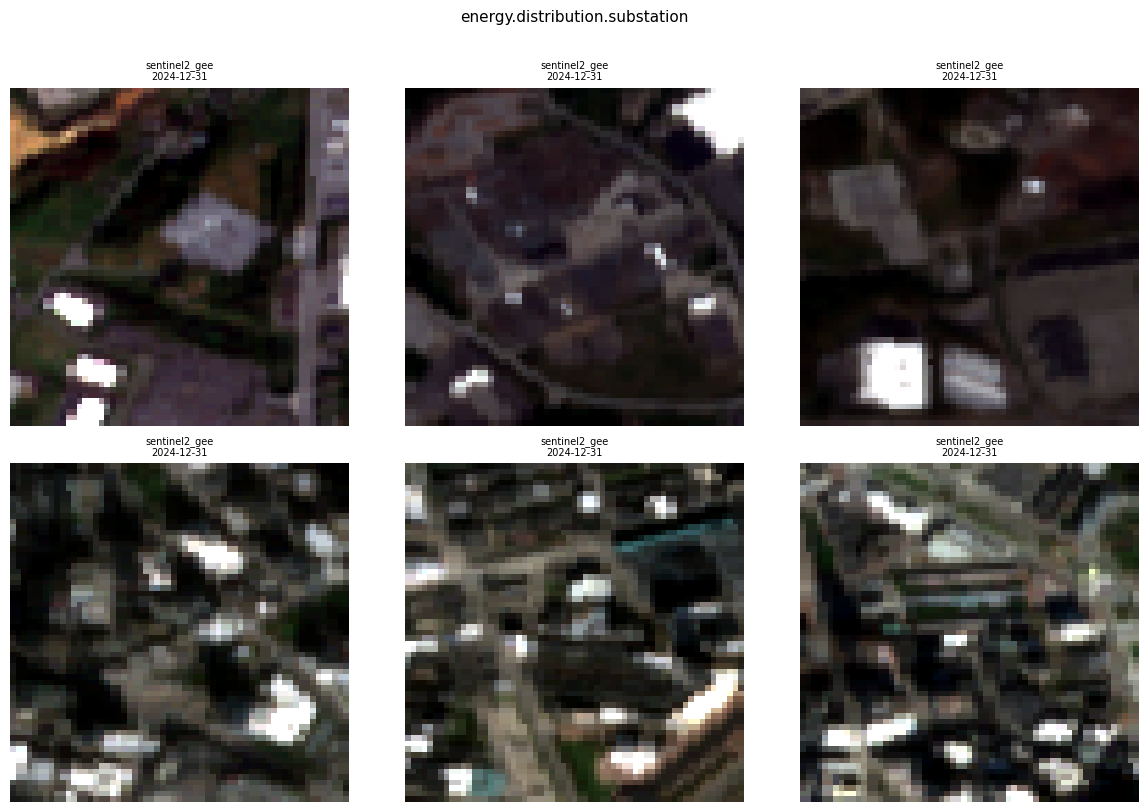

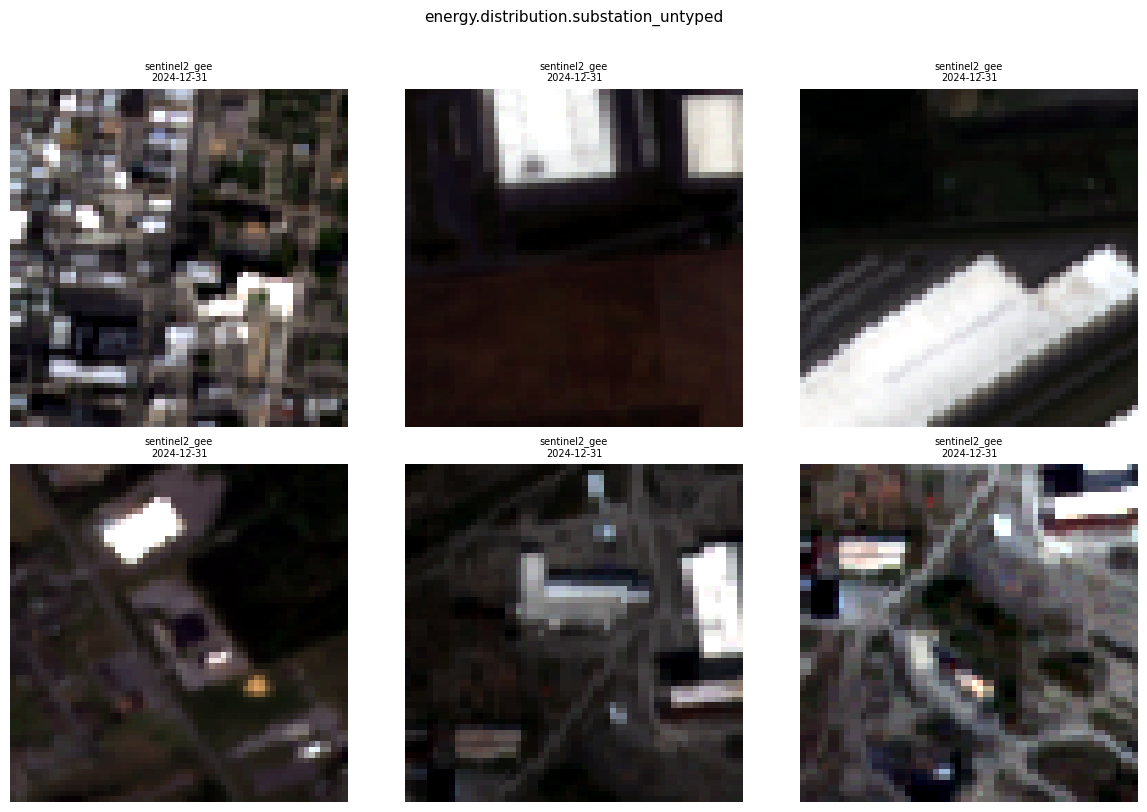

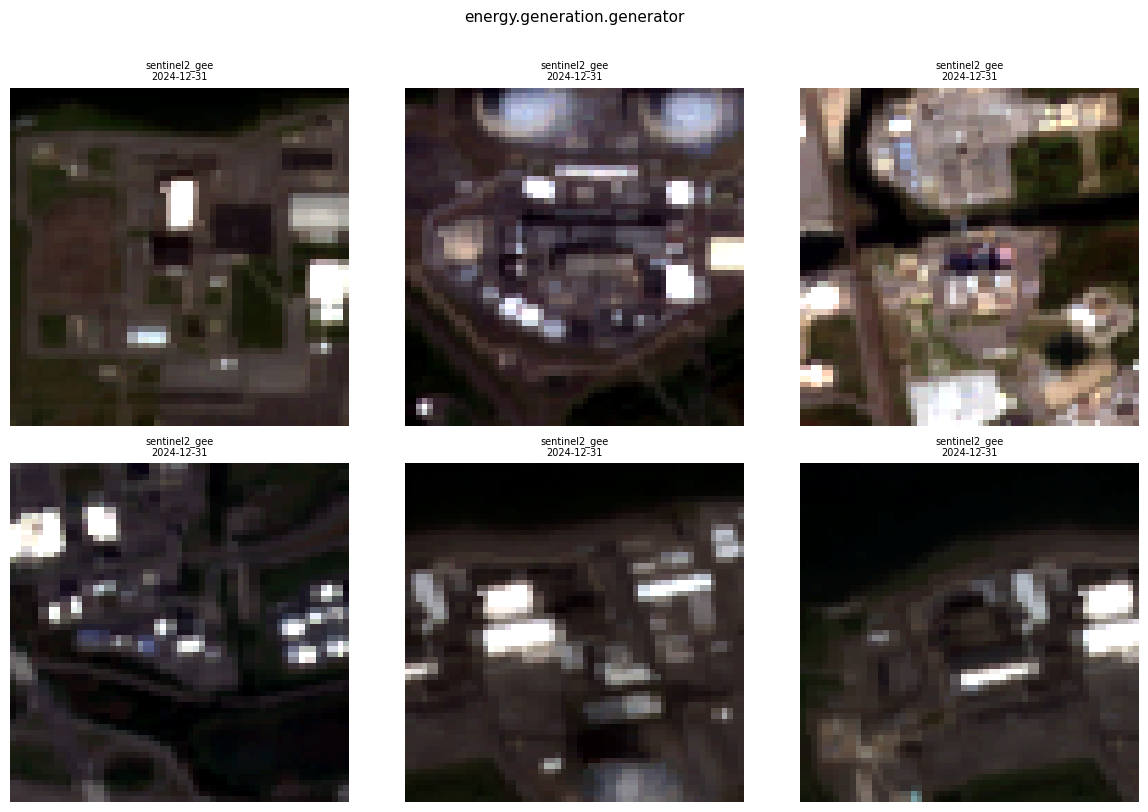

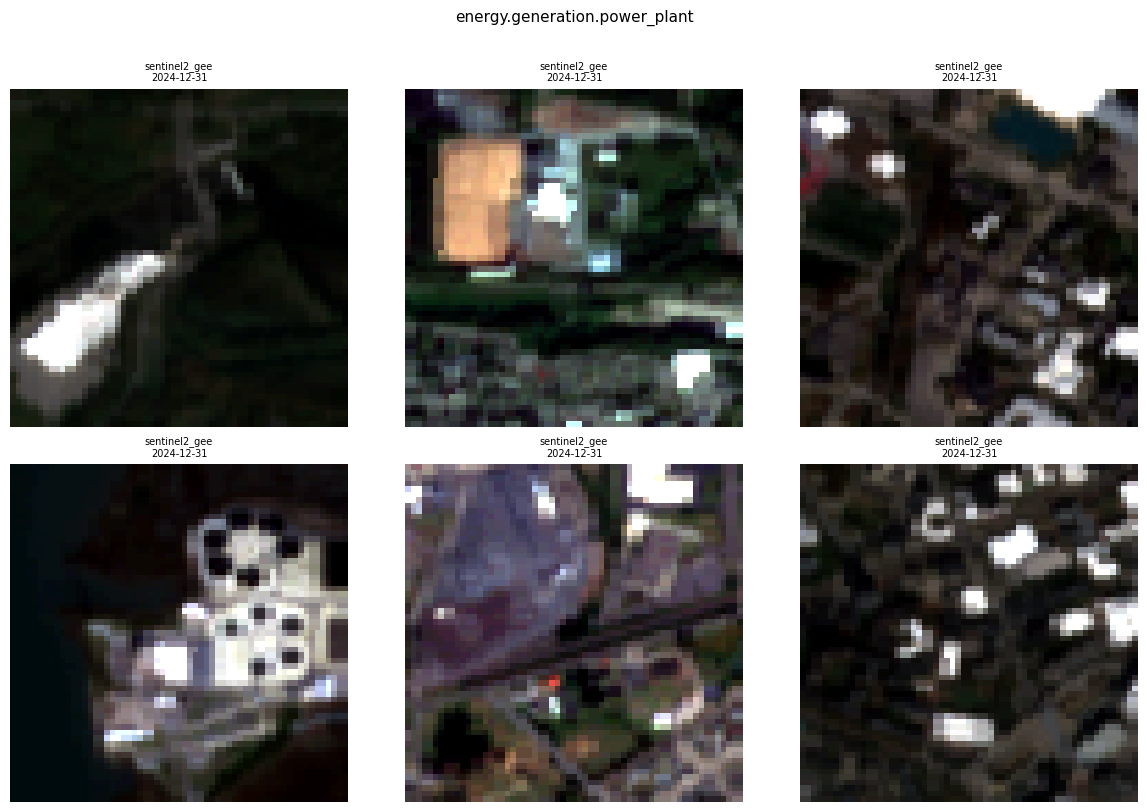

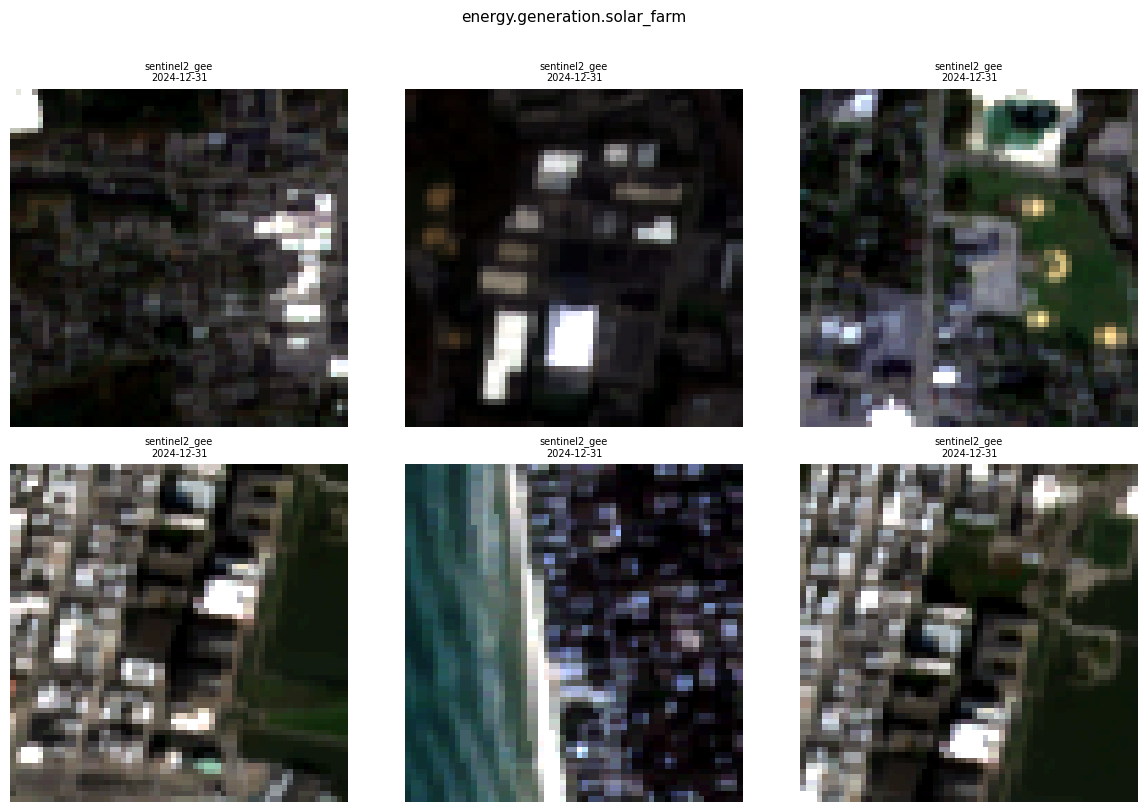

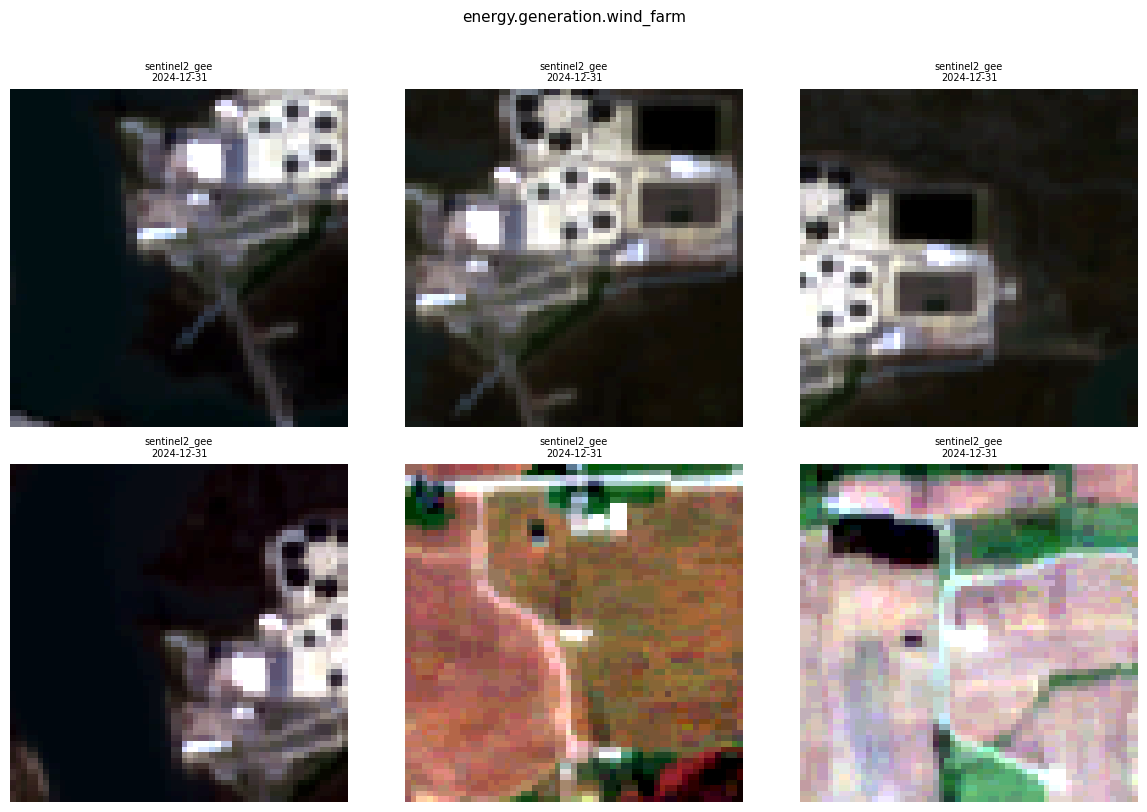

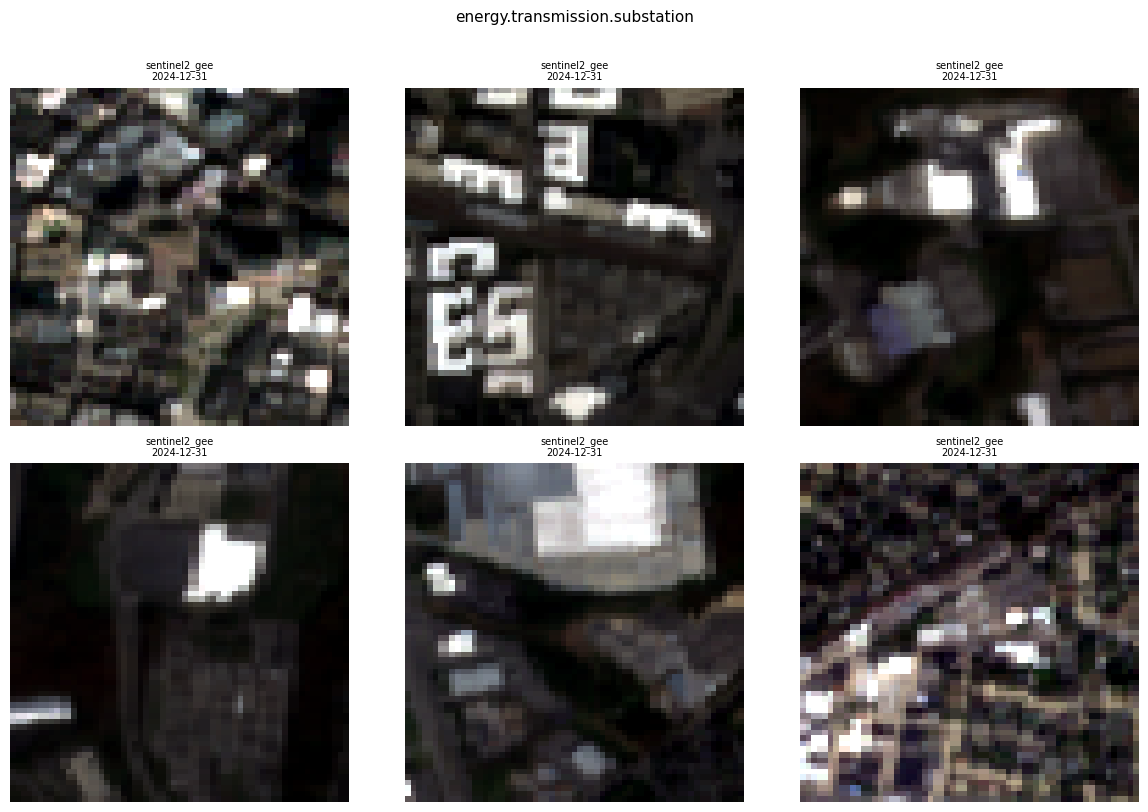

In [48]:
asset_types = df_dataset['asset_type'].unique()

for asset_type in sorted(asset_types):
    type_records = [r for r in manifest['records']
                    if r['asset_type'] == asset_type][:6]
    if not type_records:
        continue

    n      = len(type_records)
    ncols  = min(3, n)
    nrows  = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for ax, record in zip(axes, type_records):
        try:
            image = assembler.load_tile(record)
            ax.imshow(stretch_rgb(image))
        except Exception:
            ax.text(0.5, 0.5, 'load error', ha='center', va='center',
                    transform=ax.transAxes)
        ax.set_title(
            f"{record['source']}\n{record['image_date']}",
            fontsize=7,
        )
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle(asset_type, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(f"tiles_{asset_type.replace('.','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

## Dataset summary table

In [49]:
print(f'Dataset: {DATASET_DIR}')
print(f'Created: {manifest["created_at"]}')
print(f'Total tiles: {manifest["n_tiles"]}')
print()
df_dataset[['asset_type','source','image_date','confidence']].head(20)

Dataset: ./data/dataset_us-northeast_v1
Created: 2026-04-09T04:22:29.529941Z
Total tiles: 8393



,asset_type,source,image_date,confidence
0,energy.distribution.substation,sentinel2_gee,2024-12-31,high
1,energy.distribution.substation,sentinel2_gee,2024-12-31,high
2,energy.distribution.substation,sentinel2_gee,2024-12-31,high
3,energy.distribution.substation,sentinel2_gee,2024-12-31,high
4,energy.distribution.substation,sentinel2_gee,2024-12-31,high
5,energy.distribution.substation,sentinel2_gee,2024-12-31,high
6,energy.distribution.substation,sentinel2_gee,2024-12-31,high
7,energy.distribution.substation,sentinel2_gee,2024-12-31,high
8,energy.distribution.substation,sentinel2_gee,2024-12-31,high
9,energy.distribution.substation,sentinel2_gee,2024-12-31,high


## Label quality metrics
These metrics describe how trustworthy the weak labels are — 
the core question the triage step is answering.
High acceptance rate = OSM labels are consistent with imagery for that asset type.
High flag rate = OSM labels are noisy or ambiguous for that type.

In [50]:
# Load triage summary from the manifest
triage_df = pd.DataFrame([
    {
        'asset_type': r['asset_type'],
        'source':     r['source'],
        'confidence': r['confidence'],
    }
    for r in manifest['records']
])

# Also need flagged tiles — load from QC/triage if available,
# otherwise work with what's in the manifest (accepted only)
print(f'Tiles in dataset (accepted only): {len(triage_df)}')
print()
print('Confidence breakdown:')
print(triage_df['confidence'].value_counts().to_string())

Tiles in dataset (accepted only): 8393

Confidence breakdown:
confidence
high    8393


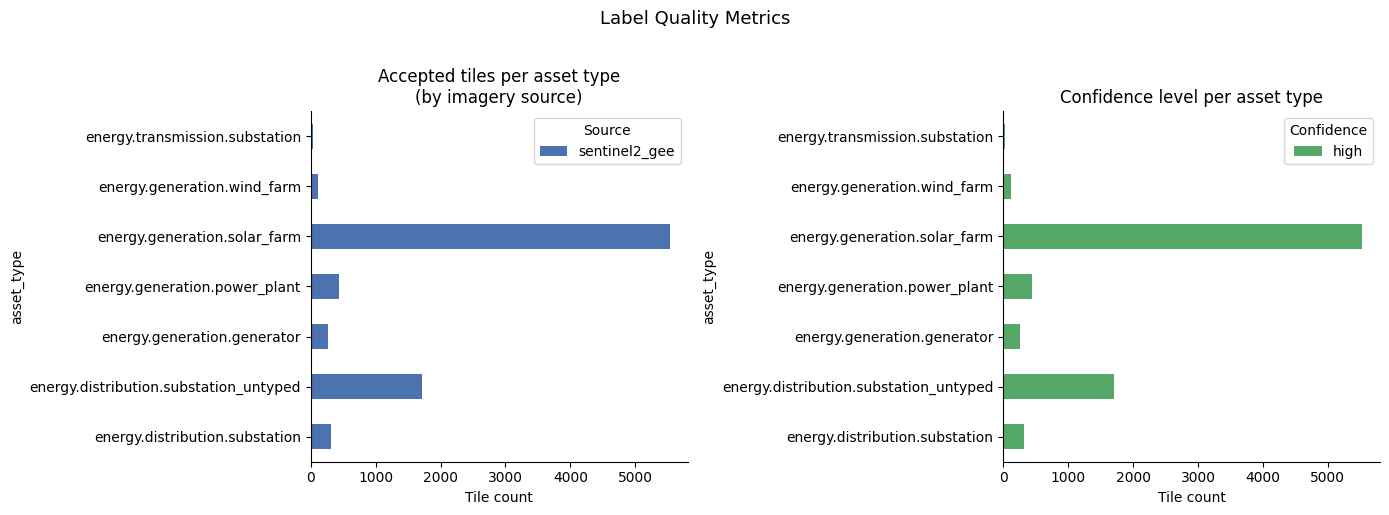

In [51]:
# Acceptance rate per asset type
# Note: manifest only contains accepted tiles.
# To get full triage breakdown, re-run triage and capture all results.
# For now we show the composition of what was accepted.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: tiles per asset type colored by source
pivot = triage_df.groupby(['asset_type','source']).size().unstack(fill_value=0)
pivot.plot(kind='barh', ax=axes[0], color=['#4C72B0','#55A868','#C44E52'][:len(pivot.columns)])
axes[0].set_title('Accepted tiles per asset type\n(by imagery source)')
axes[0].set_xlabel('Tile count')
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(title='Source')

# Right: confidence distribution per asset type
conf_pivot = triage_df.groupby(['asset_type','confidence']).size().unstack(fill_value=0)
conf_colors = {'high':'#55A868','low':'#CCB974','contradiction':'#C44E52'}
conf_pivot.plot(kind='barh', ax=axes[1],
    color=[conf_colors.get(c,'#4C72B0') for c in conf_pivot.columns])
axes[1].set_title('Confidence level per asset type')
axes[1].set_xlabel('Tile count')
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend(title='Confidence')

plt.suptitle('Label Quality Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('label_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal distributions by asset type
These show what the triage step is actually measuring.
Well-separated distributions between asset types = the signals are
capturing real visual differences, not noise.

In [52]:
# Load signal data from manifest records
# (only present if triage was run with RuleBasedTriager)
signal_rows = []
for r in manifest['records']:
    row = {'asset_type': r['asset_type'], 'source': r['source']}
    # signals aren't stored in manifest by default — compute from saved tiles
    signal_rows.append(row)

# Compute texture and brightness from saved tiles
print('Computing signals from saved tiles...')
from triage import _extract_signals
from imagery import TileResult

sig_rows = []
for r in manifest['records']:
    try:
        image = assembler.load_tile(r)
        # create a minimal TileResult to pass to _extract_signals
        dummy = TileResult(
            asset_id=r['asset_id'], asset_type=r['asset_type'],
            lat=r['lat'], lon=r['lon'], bbox=tuple(r['bbox']),
            source=r['source'], image=image,
        )
        sigs = _extract_signals(dummy)
        sigs['asset_type'] = r['asset_type']
        sigs['source']     = r['source']
        sig_rows.append(sigs)
    except Exception as e:
        pass

sig_df = pd.DataFrame(sig_rows)
print(f'Computed signals for {len(sig_df)} tiles')
sig_df.head()

Computing signals from saved tiles...
Computed signals for 8393 tiles


,mean_brightness,std_brightness,rg_ratio,rb_ratio,texture,valid_ratio,center_brightness,center_vs_full,asset_type,source
0,20.719162,16.877940,0.967335,1.393504,7.026503,1.0,16.792963,0.810504,energy.distribution.substation,sentinel2_gee
1,30.434202,21.140424,1.080991,1.391576,8.635792,1.0,30.037407,0.986962,energy.distribution.substation,sentinel2_gee
2,27.329840,23.650796,1.069001,1.379504,8.162842,1.0,22.788519,0.833833,energy.distribution.substation,sentinel2_gee
3,23.904775,21.174532,1.068006,1.167616,12.581694,1.0,25.218519,1.054957,energy.distribution.substation,sentinel2_gee
4,24.805429,16.888268,1.059114,1.163066,11.662842,1.0,23.369259,0.942103,energy.distribution.substation,sentinel2_gee


C:\Users\guthrie.j\AppData\Local\Temp\ipykernel_20700\781713018.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(asset_types))


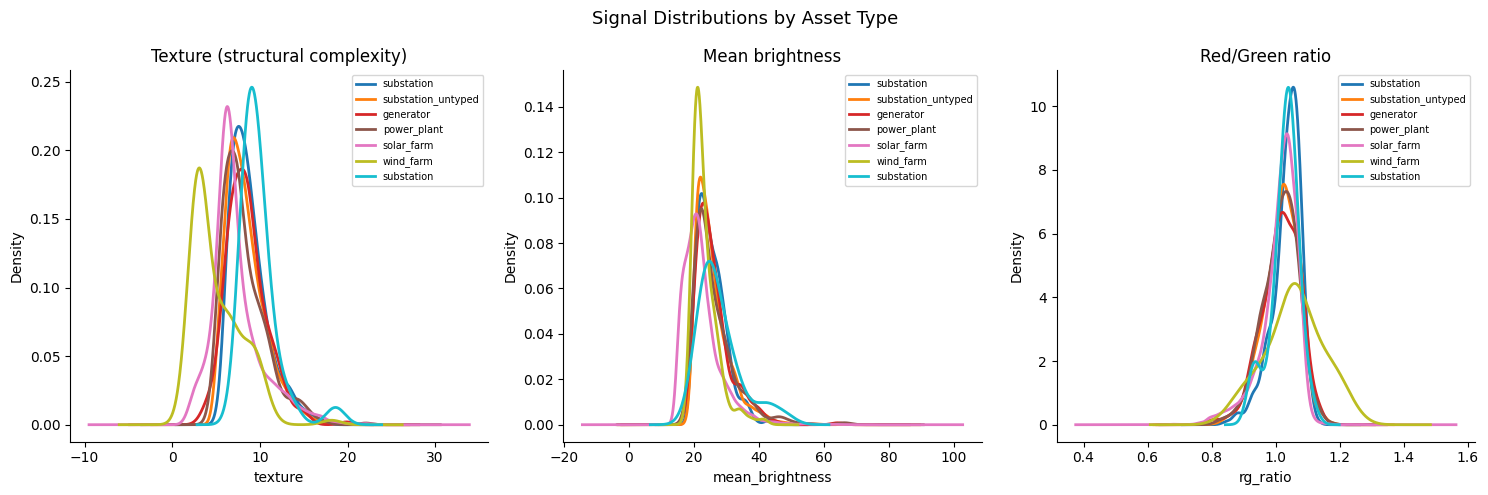

Well-separated distributions = signals capture real visual differences


In [53]:
if not sig_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    signals_to_plot = [
        ('texture',         'Texture (structural complexity)'),
        ('mean_brightness',  'Mean brightness'),
        ('rg_ratio',         'Red/Green ratio'),
    ]

    asset_types = sig_df['asset_type'].unique()
    cmap = plt.cm.get_cmap('tab10', len(asset_types))
    color_map = {at: cmap(i) for i, at in enumerate(sorted(asset_types))}

    for ax, (signal, label) in zip(axes, signals_to_plot):
        for asset_type in sorted(asset_types):
            subset = sig_df[sig_df['asset_type'] == asset_type][signal].dropna()
            if len(subset) > 1:
                subset.plot.kde(ax=ax, label=asset_type.split('.')[-1],
                                color=color_map[asset_type], linewidth=2)
            elif len(subset) == 1:
                ax.axvline(subset.iloc[0], color=color_map[asset_type],
                           linewidth=2, label=asset_type.split('.')[-1])
        ax.set_title(label)
        ax.set_xlabel(signal)
        ax.spines[['top','right']].set_visible(False)
        ax.legend(fontsize=7)

    plt.suptitle('Signal Distributions by Asset Type', fontsize=13)
    plt.tight_layout()
    plt.savefig('signal_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Well-separated distributions = signals capture real visual differences')

## Spatial coverage map
Shows where the accepted tiles are geographically.
Good geographic spread = the corpus is not dominated by one region.

C:\Users\guthrie.j\AppData\Local\Temp\ipykernel_20700\3603082340.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = plt.cm.get_cmap('tab10', len(asset_types_unique))


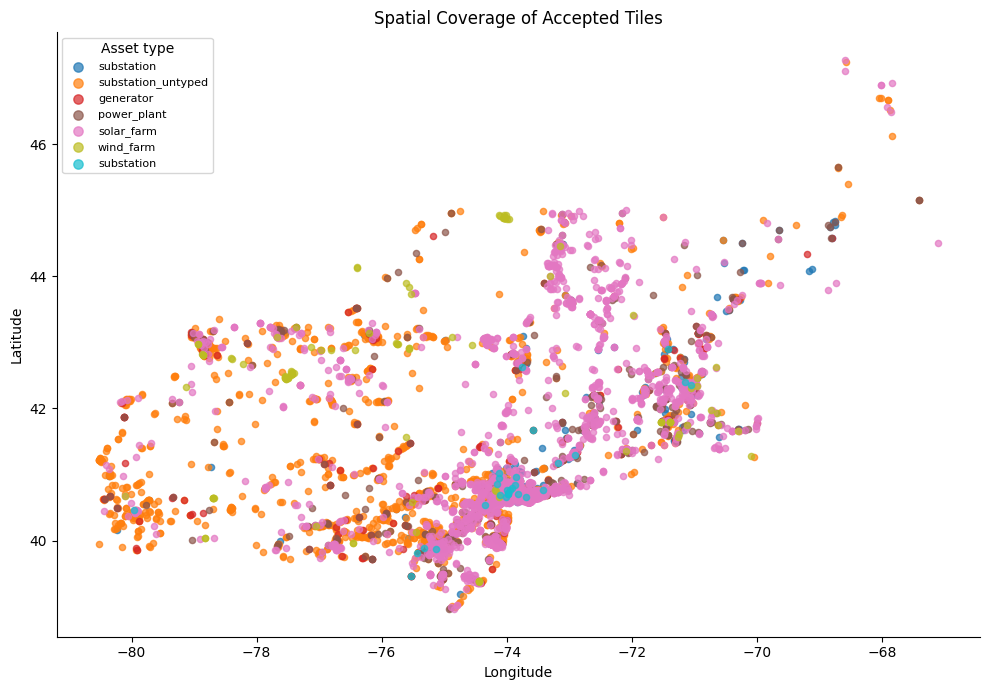

In [54]:
lats = [r['lat'] for r in manifest['records']]
lons = [r['lon'] for r in manifest['records']]
types = [r['asset_type'] for r in manifest['records']]

fig, ax = plt.subplots(figsize=(10, 7))

asset_types_unique = sorted(set(types))
cmap2 = plt.cm.get_cmap('tab10', len(asset_types_unique))
color_map2 = {at: cmap2(i) for i, at in enumerate(asset_types_unique)}

for asset_type in asset_types_unique:
    mask = [t == asset_type for t in types]
    ax.scatter(
        [lons[i] for i, m in enumerate(mask) if m],
        [lats[i] for i, m in enumerate(mask) if m],
        c=[color_map2[asset_type]],
        label=asset_type.split('.')[-1],
        s=20, alpha=0.7,
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Coverage of Accepted Tiles')
ax.legend(title='Asset type', fontsize=8, markerscale=1.5)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('spatial_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
import json
with open("data/gold/infra-fm-gold-subset.geojson") as f:
    gj = json.load(f)
types = set(f["properties"].get("FIRST_Node_Type") for f in gj["features"])
tdgs  = set(f["properties"].get("FIRST_TDG") for f in gj["features"])
print("Node types:", types)
print("TDG values:", tdgs)

Node types: {'SUBSTATION', 'TAP', 'SWITCH', 'GENERATOR', 'SUPPORT'}
TDG values: {'TG', 'T?', 'D?', 'D', 'UNKNOWN', 'TD', 'TDG', 'TD?', 'G', 'T'}


## Summary statistics table
Clean table suitable for a paper or presentation.

In [55]:
summary_stats = triage_df.groupby('asset_type').agg(
    tiles=('confidence', 'count'),
    high_conf=('confidence', lambda x: (x=='high').sum()),
    low_conf=('confidence', lambda x: (x=='low').sum()),
).reset_index()

summary_stats['acceptance_rate_%'] = (
    summary_stats['high_conf'] / summary_stats['tiles'] * 100
).round(1)

# Add source breakdown
source_counts = triage_df.groupby(['asset_type','source']).size().unstack(fill_value=0)
summary_stats = summary_stats.merge(source_counts, on='asset_type', how='left')

print('=== Dataset Quality Summary ===')
print(summary_stats.to_string(index=False))
summary_stats

=== Dataset Quality Summary ===
                            asset_type  tiles  high_conf  low_conf  acceptance_rate_%  sentinel2_gee
        energy.distribution.substation    318        318         0              100.0            318
energy.distribution.substation_untyped   1710       1710         0              100.0           1710
           energy.generation.generator    258        258         0              100.0            258
         energy.generation.power_plant    438        438         0              100.0            438
          energy.generation.solar_farm   5528       5528         0              100.0           5528
           energy.generation.wind_farm    112        112         0              100.0            112
        energy.transmission.substation     29         29         0              100.0             29


,asset_type,tiles,high_conf,low_conf,acceptance_rate_%,sentinel2_gee
0,energy.distribution.substation,318,318,0,100.0,318
1,energy.distribution.substation_untyped,1710,1710,0,100.0,1710
2,energy.generation.generator,258,258,0,100.0,258
3,energy.generation.power_plant,438,438,0,100.0,438
4,energy.generation.solar_farm,5528,5528,0,100.0,5528
5,energy.generation.wind_farm,112,112,0,100.0,112
6,energy.transmission.substation,29,29,0,100.0,29


## Pipeline yield rate

In [56]:
if len(df_raw) > 0 and len(df_dataset) > 0:
    print('Pipeline yield rates:')
    print(f'  Extraction → dataset:  {len(df_dataset)/len(df_raw)*100:.1f}%')
    if len(df_deduped) > 0:
        print(f'  After dedup → dataset: {len(df_dataset)/len(df_deduped)*100:.1f}% of imagery attempts')
    print()
    print('Tiles per asset type in final dataset:')
    print(df_dataset.groupby(["asset_type","source"]).size().unstack(fill_value=0).to_string())

Pipeline yield rates:
  Extraction → dataset:  13.7%
  After dedup → dataset: 39.0% of imagery attempts

Tiles per asset type in final dataset:
source                                  sentinel2_gee
asset_type                                           
energy.distribution.substation                    318
energy.distribution.substation_untyped           1710
energy.generation.generator                       258
energy.generation.power_plant                     438
energy.generation.solar_farm                     5528
energy.generation.wind_farm                       112
energy.transmission.substation                     29


# pretraining results

Found 43 files
osm_node_12641214584_sentinel2_gee.npy (3, 61, 61) uint8 3 128
osm_way_1024557507_sentinel2_gee.npy (3, 61, 61) uint8 2 66
osm_way_1303315639_sentinel2_gee.npy (3, 61, 61) uint8 4 60
osm_way_133801192_sentinel2_gee.npy (3, 61, 61) uint8 0 98
osm_way_136694712_sentinel2_gee.npy (3, 61, 61) uint8 0 124
osm_way_136694713_sentinel2_gee.npy (3, 61, 61) uint8 2 88
osm_way_141341458_sentinel2_gee.npy (3, 61, 61) uint8 3 49
osm_way_141341463_sentinel2_gee.npy (3, 61, 61) uint8 4 126
osm_way_142752409_sentinel2_gee.npy (3, 61, 61) uint8 5 78


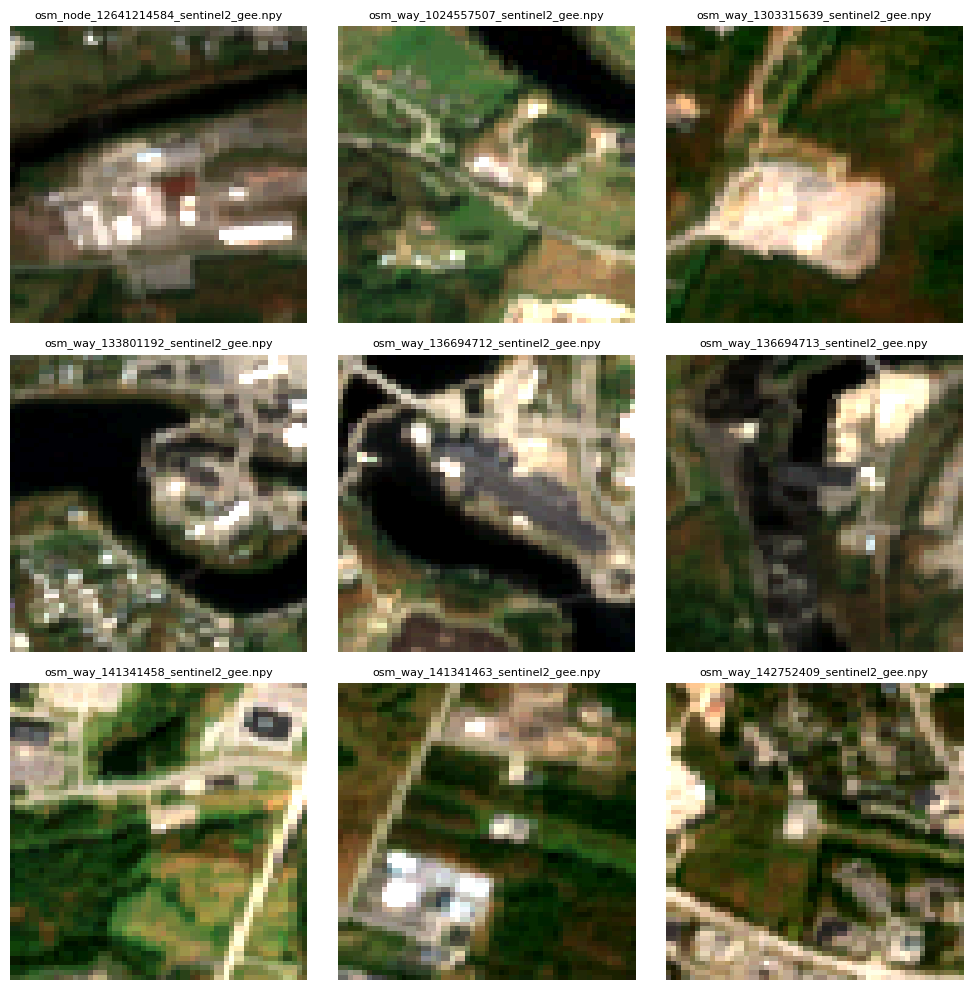

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

dataset_root = r"data/curated_datasets/dataset_maine_v1"
image_dir = os.path.join(dataset_root, "images")
files = sorted(glob.glob(os.path.join(image_dir, "*.npy")))

print(f"Found {len(files)} files")

for path in files[:9]:
    arr = np.load(path)
    print(os.path.basename(path), arr.shape, arr.dtype, np.nanmin(arr), np.nanmax(arr))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, path in zip(axes, files[:9]):
    arr = np.load(path)

    if arr.ndim == 3 and arr.shape[0] <= 20:   # CHW
        arr = np.transpose(arr, (1, 2, 0))

    # choose first 3 channels for now
    img = arr[..., :3].astype(np.float32)

    # simple percentile stretch
    lo = np.percentile(img, 2)
    hi = np.percentile(img, 98)
    img = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

    ax.imshow(img)
    ax.set_title(os.path.basename(path), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()